In [5]:
import yfinance as yf
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

In [6]:
spy = yf.Ticker("SPY")   # SPDR S&P 500 ETF
voo = yf.Ticker("VOO")   # Vanguard S&P 500 ETF
ivv = yf.Ticker("IVV")   # iShares Core S&P 500 ETF

In [7]:
data = yf.download("SPY", start="2020-01-01", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [8]:
# closing price only
spy_close = data["Close"]
spy_close.columns.name = None   # drop the "Ticker" column label
spy_close = spy_close.rename(columns={"SPY": "close"})
spy_close.tail()

,close
Date,
2026-09-09,762.400024
2026-09-10,757.830017
2026-09-11,764.289978
2026-09-14,760.880005
2026-09-15,757.390015


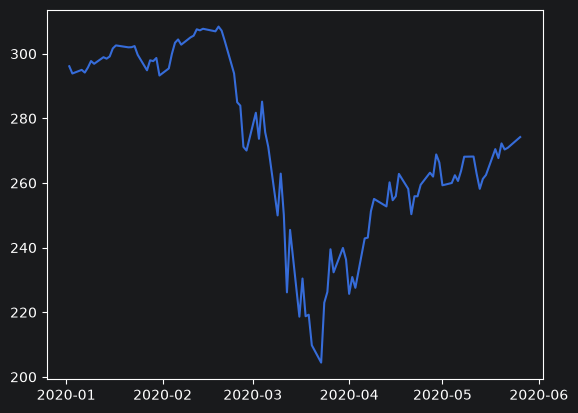

In [10]:
plt.plot(spy_close[:100])

In [11]:
# market making quotes: bid/ask one standard deviation either side of the 7-day moving average
window = 7
num_std = 1

quotes = spy_close.copy()
quotes["ma"] = quotes["close"].rolling(window).mean()
quotes["std"] = quotes["close"].rolling(window).std()
quotes["bid"] = quotes["ma"] - num_std * quotes["std"]
quotes["ask"] = quotes["ma"] + num_std * quotes["std"]
quotes["spread"] = quotes["ask"] - quotes["bid"]

# quotes are set from the trailing window, so shift by 1 to avoid using today's close in today's quote
quotes[["ma", "std", "bid", "ask", "spread"]] = quotes[["ma", "std", "bid", "ask", "spread"]].shift(1)
quotes = quotes.dropna()
quotes.tail()

,close,ma,std,bid,ask,spread
Date,,,,,,
2026-09-09,762.400024,767.522853,3.732100,763.790754,771.254953,7.464199
2026-09-10,757.830017,766.530003,4.073822,762.456181,770.603825,8.147644
2026-09-11,764.289978,765.212864,5.209791,760.003073,770.422656,10.419582
2026-09-14,760.880005,765.571429,5.016953,760.554475,770.588382,10.033907
2026-09-15,757.390015,764.960005,5.326697,759.633307,770.286702,10.653394


In [12]:
# fills: price trading through our quote lifts the ask / hits the bid
quotes["fill"] = 0
quotes.loc[quotes["close"] <= quotes["bid"], "fill"] = 1    # we buy at the bid
quotes.loc[quotes["close"] >= quotes["ask"], "fill"] = -1   # we sell at the ask

fill_rate = (quotes["fill"] != 0).mean()
print(f"days quoted:  {len(quotes)}")
print(f"bid hit:      {(quotes['fill'] == 1).sum()}")
print(f"ask lifted:   {(quotes['fill'] == -1).sum()}")
print(f"fill rate:    {fill_rate:.1%}")
print(f"avg spread:   ${quotes['spread'].mean():.2f}  ({(quotes['spread'] / quotes['ma']).mean():.2%} of price)")

days quoted:  1677
bid hit:      356
ask lifted:   663
fill rate:    60.8%
avg spread:   $9.56  (2.20% of price)


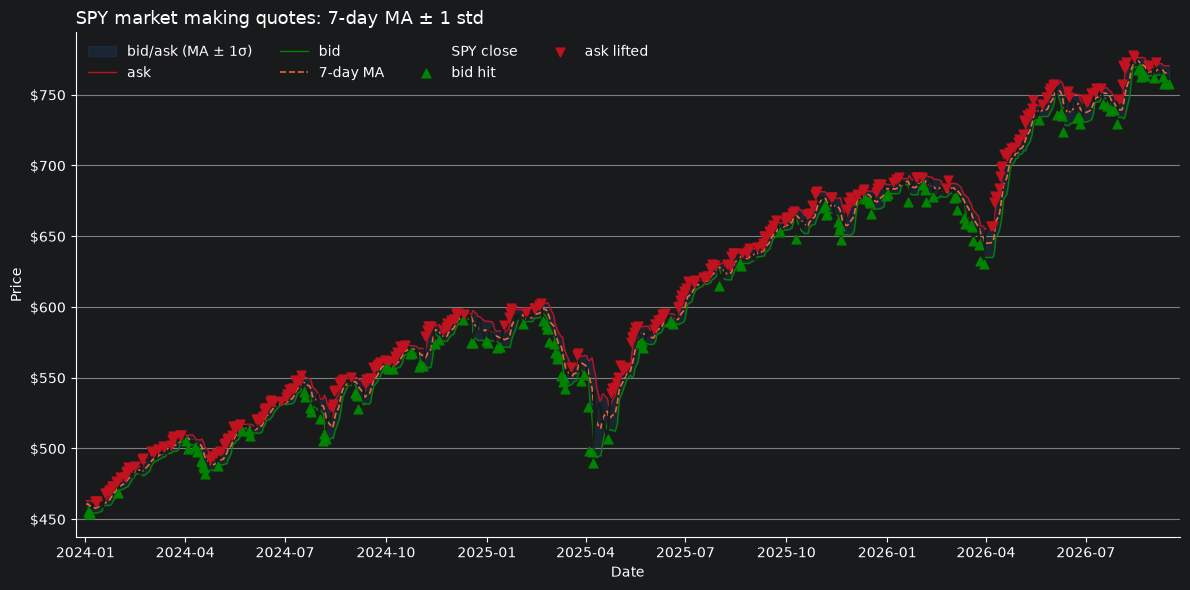

In [13]:
plot = quotes.loc["2024-01-01":]

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(plot.index, plot["bid"], plot["ask"], color="#2a78d6", alpha=0.12, label=f"bid/ask (MA ± {num_std}σ)")
ax.plot(plot.index, plot["ask"], color="#c1121f", linewidth=1, label="ask")
ax.plot(plot.index, plot["bid"], color="#008300", linewidth=1, label="bid")
ax.plot(plot.index, plot["ma"], color="#eb6834", linewidth=1.2, linestyle="--", label=f"{window}-day MA")
ax.plot(plot.index, plot["close"], color="#1a1a19", linewidth=1.6, label="SPY close")

buys, sells = plot[plot["fill"] == 1], plot[plot["fill"] == -1]
ax.scatter(buys.index, buys["close"], marker="^", s=40, color="#008300", zorder=3, label="bid hit")
ax.scatter(sells.index, sells["close"], marker="v", s=40, color="#c1121f", zorder=3, label="ask lifted")

ax.set_title(f"SPY market making quotes: {window}-day MA ± {num_std} std", fontsize=13, loc="left")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("${x:,.0f}"))
ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", frameon=False, ncol=4)
ax.margins(x=0.01)
fig.tight_layout()
plt.show()

In [14]:
# portfolio: start with $10,000 cash, trade 1 share per fill at our quoted price
starting_cash = 10_000
lot = 1

cash = starting_cash
position = 0
cash_hist, pos_hist, trade_px = [], [], []

for date, row in quotes.iterrows():
    if row["fill"] == 1:        # bid hit -> we buy at our bid
        cash -= lot * row["bid"]
        position += lot
        trade_px.append(row["bid"])
    elif row["fill"] == -1:     # ask lifted -> we sell at our ask (can go short)
        cash += lot * row["ask"]
        position -= lot
        trade_px.append(row["ask"])
    else:
        trade_px.append(np.nan)
    cash_hist.append(cash)
    pos_hist.append(position)

portfolio = pd.DataFrame({
    "close": quotes["close"],
    "fill": quotes["fill"],
    "trade_price": trade_px,
    "position": pos_hist,
    "cash": cash_hist,
}, index=quotes.index)
portfolio["inventory_value"] = portfolio["position"] * portfolio["close"]   # mark-to-market
portfolio["equity"] = portfolio["cash"] + portfolio["inventory_value"]
portfolio["pnl"] = portfolio["equity"] - starting_cash
portfolio.tail()

,close,fill,trade_price,position,cash,inventory_value,equity,pnl
Date,,,,,,,,
2026-09-09,762.400024,1,763.790754,-309,155056.447645,-235581.607544,-80525.159899,-90525.159899
2026-09-10,757.830017,1,762.456181,-308,154293.991464,-233411.645264,-79117.653800,-89117.653800
2026-09-11,764.289978,0,NaN,-308,154293.991464,-235401.313232,-81107.321769,-91107.321769
2026-09-14,760.880005,0,NaN,-308,154293.991464,-234351.041504,-80057.050040,-90057.050040
2026-09-15,757.390015,1,759.633307,-307,153534.358156,-232518.734497,-78984.376341,-88984.376341


In [15]:
final = portfolio.iloc[-1]
daily_ret = portfolio["equity"].pct_change().dropna()
drawdown = portfolio["equity"] / portfolio["equity"].cummax() - 1

print(f"starting cash:    ${starting_cash:,.2f}")
print(f"final equity:     ${final['equity']:,.2f}")
print(f"total P&L:        ${final['pnl']:,.2f}  ({final['pnl'] / starting_cash:+.2%})")
print(f"  realised cash:  ${final['cash'] - starting_cash:,.2f}")
print(f"  open inventory: {final['position']:+.0f} shares  (${final['inventory_value']:,.2f})")
print(f"trades:           {(portfolio['fill'] != 0).sum()}")
print(f"max inventory:    {portfolio['position'].abs().max():.0f} shares")
print(f"max drawdown:     {drawdown.min():.2%}")
print(f"sharpe (daily):   {daily_ret.mean() / daily_ret.std() * np.sqrt(252):.2f}")

starting cash:    $10,000.00
final equity:     $-78,984.38
total P&L:        $-88,984.38  (-889.84%)
  realised cash:  $143,534.36
  open inventory: -307 shares  ($-232,518.73)
trades:           1019
max inventory:    313 shares
max drawdown:     -918.17%
sharpe (daily):   -0.08


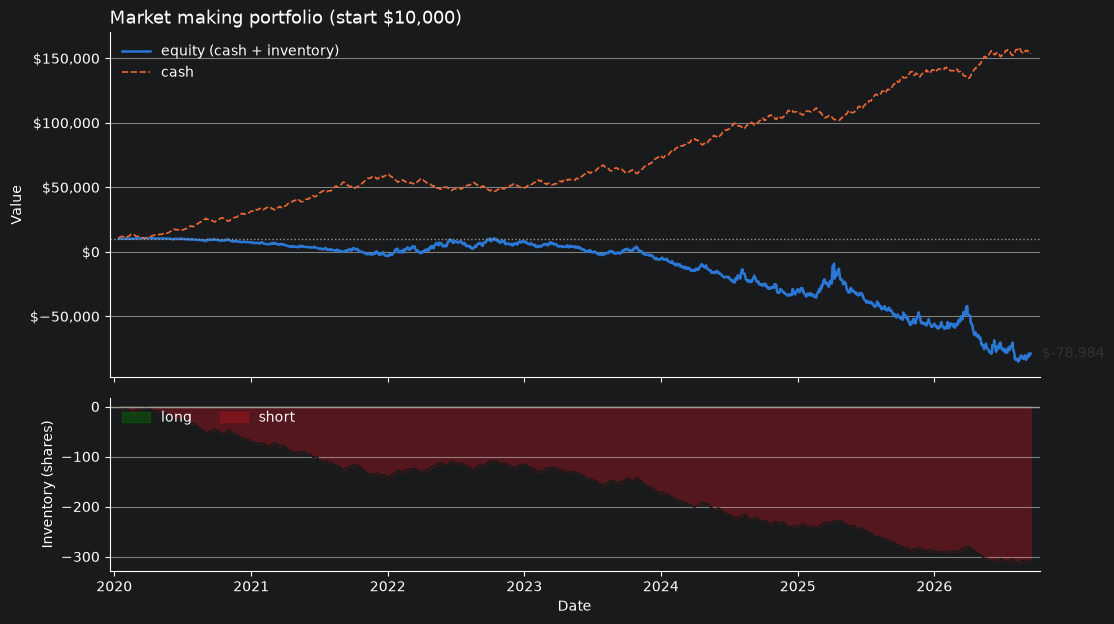

In [16]:
 fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08})

ax1.plot(portfolio.index, portfolio["equity"], color="#2a78d6", linewidth=1.8, label="equity (cash + inventory)")
ax1.plot(portfolio.index, portfolio["cash"], color="#eb6834", linewidth=1.2, linestyle="--", label="cash")
ax1.axhline(starting_cash, color="#999999", linewidth=1, linestyle=":")
ax1.annotate(f"${portfolio['equity'].iloc[-1]:,.0f}", xy=(portfolio.index[-1], portfolio["equity"].iloc[-1]),
             xytext=(8, 0), textcoords="offset points", va="center", fontsize=10, color="#333333")
ax1.set_title("Market making portfolio (start $10,000)", fontsize=13, loc="left")
ax1.set_ylabel("Value")
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("${x:,.0f}"))
ax1.legend(loc="upper left", frameon=False)

ax2.fill_between(portfolio.index, 0, portfolio["position"].clip(lower=0), step="post", color="#008300", alpha=0.35, label="long")
ax2.fill_between(portfolio.index, 0, portfolio["position"].clip(upper=0), step="post", color="#c1121f", alpha=0.35, label="short")
ax2.plot(portfolio.index, portfolio["position"], color="#1a1a19", linewidth=1, drawstyle="steps-post")
ax2.axhline(0, color="#999999", linewidth=1)
ax2.set_ylabel("Inventory (shares)")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left", frameon=False, ncol=2)

for ax in (ax1, ax2):
    ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(x=0.01)

plt.show()